<a href="https://colab.research.google.com/github/AntonDozhdikov/AntonDozhdikov/blob/main/final_exp_DGM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🎓 Моделирование оптимизации распределения контрольных цифр приема в вузы
📋 Описание проекта
Реализация многоагентной системы оптимизации деятельности 15 вузов с использованием алгоритмов MADDPG и Дарвин-Гёдель машины для максимизации прибыли вузов и удовлетворения запросов экономики.

In [15]:
# 🚀 Импорт необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from collections import deque
import random
import time
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# 📊 Настройка стиля визуализации
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

🏫 Модель системы высшего образования


In [16]:
class UniversityEnvironment:
    """
    🏫 Модель среды для симуляции системы высшего образования
    """

    def __init__(self, num_universities=15, num_directions=10, num_regions=15, num_features=12):
        """
        🎯 Инициализация среды

        Args:
            num_universities: Количество вузов (15)
            num_directions: Количество направлений подготовки (10)
            num_regions: Количество регионов (15)
            num_features: Количество признаков вуза (12)
        """
        self.num_universities = num_universities
        self.num_directions = num_directions
        self.num_regions = num_regions
        self.num_features = num_features

        # 📈 Инициализация вузов со случайными параметрами
        self.universities = self._initialize_universities()

        # 🌍 Инициализация регионов и спроса
        self.regions = self._initialize_regions()

        # 📊 Инициализация направлений подготовки
        self.directions = self._initialize_directions()

        # 📅 Инициализация факторов влияния
        self.influence_factors = self._initialize_influence_factors()

        # 📊 Инициализация спроса по регионам
        self.demand_by_region = self._initialize_demand()

        # 📊 Метрики для мониторинга
        self.metrics_history = {
            'total_reward': [],
            'average_reward': [],
            'profitability': [],
            'demand_satisfaction': [],
            'federal_compliance': [],
            'employment_rate': [],
            'quality_score': [],
            'budget_ratio_deviation': []
        }

        # ⏰ Таймер эксперимента
        self.start_time = time.time()

    def _initialize_universities(self):
        """
        🏫 Инициализация вузов со случайными параметрами
        """
        universities = {}
        for i in range(self.num_universities):
            universities[f'university_{i}'] = {
                'id': i,
                'name': f'University_{i}',
                'region': random.randint(0, self.num_regions - 1),
                'capacity': random.randint(8000, 15000),  # Вместимость вуза
                'budget_ratio': 0.7 + random.uniform(-0.1, 0.1),  # Доля бюджетных мест
                'quality_score': random.uniform(0.6, 1.0),  # Качество образования
                'reputation': random.uniform(0.5, 1.0),  # Репутация
                'employment_rate': random.uniform(0.7, 0.95),  # Уровень трудоустройства
                'faculty_quality': random.uniform(0.6, 1.0),  # Качество преподавателей
                'infrastructure': random.uniform(0.5, 1.0),  # Инфраструктура
                'research_output': random.uniform(0.4, 1.0),  # Научная активность
                'international_students': random.uniform(0.05, 0.2),  # Доля иностранных студентов
                'alumni_network': random.uniform(0.4, 0.9),  # Сила выпускной сети
                'financial_stability': random.uniform(0.6, 1.0),  # Финансовая устойчивость
            }
        return universities

    def _initialize_regions(self):
        """
        🌍 Инициализация регионов
        """
        regions = {}
        for i in range(self.num_regions):
            regions[f'region_{i}'] = {
                'id': i,
                'name': f'Region_{i}',
                'economic_index': random.uniform(0.6, 1.0),  # Экономический индекс
                'population': random.randint(500000, 3000000),  # Население
                'industry_diversity': random.uniform(0.5, 1.0),  # Разнообразие отраслей
                'migration_rate': random.uniform(-0.02, 0.05),  # Миграционный поток
                'development_level': random.uniform(0.4, 1.0),  # Уровень развития
            }
        return regions

    def _initialize_directions(self):
        """
        📚 Инициализация направлений подготовки
        """
        directions = [
            'Computer Science', 'Engineering', 'Medicine', 'Economics',
            'Law', 'Psychology', 'Business', 'Mathematics', 'Physics', 'Chemistry'
        ]
        return directions

    def _initialize_influence_factors(self):
        """
        📊 Инициализация факторов влияния на спрос
        """
        factors = {
            # 📈 Регулярные факторы (±20% в год)
            'inflation': {'base_impact': 0.05, 'volatility': 0.2, 'annual_change': True},
            'legislation': {'base_impact': 0.03, 'volatility': 0.2, 'annual_change': True},
            'migration': {'base_impact': 0.04, 'volatility': 0.2, 'annual_change': True},
            'employment': {'base_impact': 0.06, 'volatility': 0.2, 'annual_change': True},
            'technology': {'base_impact': 0.07, 'volatility': 0.2, 'annual_change': True},
            'demographics': {'base_impact': 0.05, 'volatility': 0.2, 'annual_change': True},
            'competition': {'base_impact': 0.04, 'volatility': 0.2, 'annual_change': True},

            # ⚠️ Кризисные факторы (±50% в год)
            'pandemic': {'base_impact': 0.15, 'volatility': 0.5, 'probability': 0.125},  # 1 раз в 8 лет
            'geopolitical': {'base_impact': 0.2, 'volatility': 0.5, 'probability': 0.125},
            'regulatory': {'base_impact': 0.18, 'volatility': 0.5, 'probability': 0.125}
        }
        return factors

    def _initialize_demand(self):
        """
        📊 Инициализация спроса по направлениям в регионах
        """
        demand = {}
        for region_id in range(self.num_regions):
            demand[region_id] = {}
            for direction in self.directions:
                # Базовый спрос зависит от экономического индекса региона
                base_demand = self.regions[f'region_{region_id}']['economic_index'] * 1000
                demand[region_id][direction] = base_demand * random.uniform(0.8, 1.2)
        return demand

    def reset(self):
        """
        🔄 Сброс среды к начальному состоянию
        """
        self.universities = self._initialize_universities()
        self.demand_by_region = self._initialize_demand()
        self.metrics_history = {
            'total_reward': [],
            'average_reward': [],
            'profitability': [],
            'demand_satisfaction': [],
            'federal_compliance': [],
            'employment_rate': [],
            'quality_score': [],
            'budget_ratio_deviation': []
        }
        self.start_time = time.time()
        return self._get_state()

    def _get_state(self):
        """
        📊 Получение текущего состояния среды
        """
        state = []
        for uni_id, university in self.universities.items():
            uni_state = [
                university['capacity'],
                university['budget_ratio'],
                university['quality_score'],
                university['reputation'],
                university['employment_rate'],
                university['faculty_quality'],
                university['infrastructure'],
                university['research_output'],
                university['international_students'],
                university['alumni_network'],
                university['financial_stability'],
                university['region']
            ]
            state.extend(uni_state)
        return np.array(state, dtype=np.float32)

    def _update_demand(self, year):
        """
        📈 Обновление спроса с учетом факторов влияния
        """
        for region_id in range(self.num_regions):
            region = self.regions[f'region_{region_id}']

            # 📊 Применение регулярных факторов
            for factor_name, factor in self.influence_factors.items():
                if factor_name in ['inflation', 'legislation', 'migration', 'employment',
                                 'technology', 'demographics', 'competition']:
                    # Ежегодные изменения
                    change = factor['base_impact'] + random.uniform(-factor['volatility'], factor['volatility'])
                    region['economic_index'] = np.clip(region['economic_index'] * (1 + change), 0.3, 1.0)

            # ⚠️ Применение кризисных факторов
            crisis_impact = 0
            for crisis_factor in ['pandemic', 'geopolitical', 'regulatory']:
                if random.random() < self.influence_factors[crisis_factor]['probability']:
                    crisis_change = self.influence_factors[crisis_factor]['base_impact'] + \
                                  random.uniform(-self.influence_factors[crisis_factor]['volatility'],
                                               self.influence_factors[crisis_factor]['volatility'])
                    crisis_impact += crisis_change

            if crisis_impact != 0:
                region['economic_index'] = np.clip(region['economic_index'] * (1 + crisis_impact), 0.3, 1.0)

            # 📊 Обновление спроса по направлениям
            for direction in self.directions:
                base_demand = region['economic_index'] * 1000
                self.demand_by_region[region_id][direction] = base_demand * random.uniform(0.8, 1.2)

    def step(self, actions, year):
        """
        🎮 Выполнение шага в среде

        Args:
            actions: Действия всех вузов
            year: Текущий год

        Returns:
            next_state, rewards, done, info
        """
        # 📈 Обновление спроса
        self._update_demand(year)

        # 🎯 Выполнение действий вузов
        rewards = self._execute_actions(actions)

        # 📊 Обновление метрик
        self._update_metrics(rewards)

        # 📊 Получение следующего состояния
        next_state = self._get_state()

        # 🎯 Проверка завершения эпизода
        done = year >= 23  # 24 года (0-23)

        return next_state, rewards, done, {}

    def _execute_actions(self, actions):
        """
        🎯 Выполнение действий вузов и расчет наград
        """
        rewards = []

        for i, (uni_id, action) in enumerate(zip(self.universities.keys(), actions)):
            university = self.universities[uni_id]
            reward = self._calculate_reward(university, action)
            rewards.append(reward)

            # 📊 Обновление параметров вуза на основе действия
            self._update_university(university, action)

        return rewards

    def _calculate_reward(self, university, action):
        """
        🎯 Расчет награды для вуза
        """
        # 📊 Извлечение параметров действия
        budget_ratio_change = action[0]  # Изменение доли бюджетных мест (-0.1 до 0.1)
        quality_investment = action[1]   # Инвестиции в качество (0 до 1)
        marketing_effort = action[2]     # Маркетинговые усилия (0 до 1)

        # 📊 Расчет компонентов награды
        # 💰 Прибыльность
        budget_students = university['capacity'] * university['budget_ratio']
        paid_students = university['capacity'] * (1 - university['budget_ratio'])
        profit = paid_students * 100000 - budget_students * 50000  # Упрощенная модель

        # 📊 Удовлетворение спроса
        region_id = university['region']
        demand_satisfaction = 0
        for direction in self.directions:
            actual_enrollment = university['capacity'] / len(self.directions)
            demand = self.demand_by_region[region_id][direction]
            satisfaction = min(actual_enrollment / demand, 1.0) if demand > 0 else 1.0
            demand_satisfaction += satisfaction

        demand_satisfaction /= len(self.directions)

        # 📊 Соответствие федеральным требованиям
        federal_compliance = 1.0 if abs(university['budget_ratio'] - 0.7) <= 0.1 else \
                           max(0, 1 - abs(university['budget_ratio'] - 0.7) / 0.2)

        # 📊 Качество образования
        quality_bonus = university['quality_score'] * quality_investment * 50000

        # 📊 Общая награда
        total_reward = profit * 0.00001 + demand_satisfaction * 10000 + \
                      federal_compliance * 5000 + quality_bonus * 0.001

        return total_reward

    def _update_university(self, university, action):
        """
        📊 Обновление параметров вуза на основе действия
        """
        # 📊 Извлечение параметров действия
        budget_ratio_change = np.clip(action[0], -0.1, 0.1)
        quality_investment = np.clip(action[1], 0, 1)
        marketing_effort = np.clip(action[2], 0, 1)

        # 📊 Обновление доли бюджетных мест
        university['budget_ratio'] = np.clip(university['budget_ratio'] + budget_ratio_change, 0.4, 0.9)

        # 📊 Обновление качества образования (с задержкой)
        quality_improvement = quality_investment * 0.05
        university['quality_score'] = np.clip(university['quality_score'] + quality_improvement, 0.1, 1.0)

        # 📊 Обновление репутации
        reputation_change = marketing_effort * 0.03 - 0.01  # Естественное снижение
        university['reputation'] = np.clip(university['reputation'] + reputation_change, 0.1, 1.0)

        # 📊 Обновление уровня трудоустройства
        employment_change = quality_investment * 0.02 + marketing_effort * 0.01
        university['employment_rate'] = np.clip(university['employment_rate'] + employment_change, 0.5, 1.0)

    def _update_metrics(self, rewards):
        """
        📊 Обновление метрик мониторинга
        """
        self.metrics_history['total_reward'].append(sum(rewards))
        self.metrics_history['average_reward'].append(np.mean(rewards))
        self.metrics_history['profitability'].append(np.mean(rewards) * 1000)  # Упрощенная метрика
        self.metrics_history['demand_satisfaction'].append(np.mean(rewards) / 10000)  # Упрощенная метрика
        self.metrics_history['federal_compliance'].append(1.0)  # Упрощенная метрика

        # Дополнительные метрики
        avg_employment = np.mean([uni['employment_rate'] for uni in self.universities.values()])
        avg_quality = np.mean([uni['quality_score'] for uni in self.universities.values()])
        avg_budget_deviation = np.mean([abs(uni['budget_ratio'] - 0.7) for uni in self.universities.values()])

        self.metrics_history['employment_rate'].append(avg_employment)
        self.metrics_history['quality_score'].append(avg_quality)
        self.metrics_history['budget_ratio_deviation'].append(avg_budget_deviation)

# 🎯 Создание среды
env = UniversityEnvironment()
print("🏛️ Среда высшего образования инициализирована!")
print(f"📊 Количество вузов: {env.num_universities}")
print(f"📚 Количество направлений: {env.num_directions}")
print(f"🌍 Количество регионов: {env.num_regions}")

🏛️ Среда высшего образования инициализирована!
📊 Количество вузов: 15
📚 Количество направлений: 10
🌍 Количество регионов: 15


🤖 Реализация MADDPG агента

In [17]:
class ActorNetwork(keras.Model):
    """
    🎭 Акторская сеть для MADDPG
    """

    def __init__(self, action_dim, name='actor'):
        super(ActorNetwork, self).__init__()
        self.action_dim = action_dim

        # 🧠 Архитектура сети (упрощенная для ускорения)
        self.dense1 = keras.layers.Dense(256, activation='relu', name=f'{name}_dense1')
        self.batch_norm1 = keras.layers.BatchNormalization()
        self.dense2 = keras.layers.Dense(128, activation='relu', name=f'{name}_dense2')
        self.batch_norm2 = keras.layers.BatchNormalization()
        self.output_layer = keras.layers.Dense(action_dim, activation='tanh', name=f'{name}_output')

    def call(self, state):
        x = self.dense1(state)
        x = self.batch_norm1(x)
        x = self.dense2(x)
        x = self.batch_norm2(x)
        actions = self.output_layer(x)
        return actions

class CriticNetwork(keras.Model):
    """
    🎭 Критическая сеть для MADDPG
    """

    def __init__(self, name='critic'):
        super(CriticNetwork, self).__init__()

        # 🧠 Архитектура сети (упрощенная для ускорения)
        self.dense1 = keras.layers.Dense(256, activation='relu', name=f'{name}_dense1')
        self.batch_norm1 = keras.layers.BatchNormalization()
        self.dense2 = keras.layers.Dense(128, activation='relu', name=f'{name}_dense2')
        self.batch_norm2 = keras.layers.BatchNormalization()
        self.output_layer = keras.layers.Dense(1, activation=None, name=f'{name}_output')

    def call(self, state, action):
        # 🔄 Объединение состояния и действия
        x = tf.concat([state, action], axis=1)
        x = self.dense1(x)
        x = self.batch_norm1(x)
        x = self.dense2(x)
        x = self.batch_norm2(x)
        q_value = self.output_layer(x)
        return q_value

class MADDPGAgent:
    """
    🤖 Агент MADDPG для оптимизации деятельности вуза
    """

    def __init__(self, actor_dims, critic_dims, n_actions, name,
                 alpha=0.001, beta=0.002, gamma=0.99, tau=0.005):
        """
        🎯 Инициализация агента

        Args:
            actor_dims: Размерность входа актора
            critic_dims: Размерность входа критика
            n_actions: Количество действий
            name: Имя агента
            alpha: Скорость обучения актора
            beta: Скорость обучения критика
            gamma: Коэффициент дисконтирования
            tau: Скорость обновления целевых сетей
        """
        self.gamma = gamma
        self.tau = tau
        self.n_actions = n_actions
        self.name = name

        # 🎭 Создание сетей
        self.actor = ActorNetwork(n_actions, name=f'{name}_actor')
        self.critic = CriticNetwork(name=f'{name}_critic')
        self.target_actor = ActorNetwork(n_actions, name=f'{name}_target_actor')
        self.target_critic = CriticNetwork(name=f'{name}_target_critic')

        # 🎯 Компиляция сетей
        self.actor.compile(optimizer=keras.optimizers.Adam(learning_rate=alpha))
        self.critic.compile(optimizer=keras.optimizers.Adam(learning_rate=beta))
        self.target_actor.compile(optimizer=keras.optimizers.Adam(learning_rate=alpha))
        self.target_critic.compile(optimizer=keras.optimizers.Adam(learning_rate=beta))

        # 🔄 Инициализация целевых сетей
        self.update_network_parameters(tau=1)

    def update_network_parameters(self, tau=None):
        """
        🔄 Обновление параметров целевых сетей
        """
        if tau is None:
            tau = self.tau

        # 🔄 Обновление целевого актора
        for target_param, param in zip(self.target_actor.trainable_variables,
                                     self.actor.trainable_variables):
            target_param.assign(tau * param + (1 - tau) * target_param)

        # 🔄 Обновление целевого критика
        for target_param, param in zip(self.target_critic.trainable_variables,
                                     self.critic.trainable_variables):
            target_param.assign(tau * param + (1 - tau) * target_param)

    def choose_action(self, observation):
        """
        🎯 Выбор действия на основе наблюдения
        """
        state = tf.convert_to_tensor([observation], dtype=tf.float32)
        actions = self.actor(state)
        noise = tf.random.normal(shape=[self.n_actions], mean=0.0, stddev=0.1)
        actions = actions[0] + noise
        return actions.numpy()

class MADDPGTrainer:
    """
    🏋️ Тренер для MADDPG агентов (исправленная версия)
    """

    def __init__(self, env, num_agents=15, action_dim=3, gamma=0.99):
        """
        🎯 Инициализация тренера

        Args:
            env: Среда обучения
            num_agents: Количество агентов (вузов)
            action_dim: Размерность действия каждого агента
            gamma: Коэффициент дисконтирования
        """
        self.env = env
        self.num_agents = num_agents
        self.action_dim = action_dim
        self.state_dim = len(env._get_state())
        self.gamma = gamma  # Исправлено: добавлено поле gamma

        # 🤖 Создание агентов
        self.agents = []
        for i in range(num_agents):
            agent = MADDPGAgent(
                actor_dims=self.state_dim,
                critic_dims=self.state_dim + num_agents * action_dim,
                n_actions=action_dim,
                name=f'agent_{i}',
                alpha=0.0005,  # Уменьшена скорость обучения для стабильности
                beta=0.001,
                gamma=gamma
            )
            self.agents.append(agent)

        # 📊 История обучения
        self.rewards_history = []

    def get_actions(self, observations):
        """
        🎯 Получение действий всех агентов
        """
        actions = []
        for agent, obs in zip(self.agents, observations):
            action = agent.choose_action(obs)
            actions.append(action)
        return actions

    def train_agents(self, states, actions, rewards, next_states, dones):
        """
        🏋️ Обучение всех агентов
        """
        # Подготовка всех действий для критика
        all_actions = tf.concat([tf.convert_to_tensor([action]) for action in actions], axis=1)

        # Обучение каждого агента
        for i, (agent, state, action, reward, next_state, done) in enumerate(
            zip(self.agents, states, actions, rewards, next_states, dones)):

            state_tensor = tf.convert_to_tensor([state], dtype=tf.float32)
            action_tensor = tf.convert_to_tensor([action])
            next_state_tensor = tf.convert_to_tensor([next_state], dtype=tf.float32)
            reward_tensor = tf.convert_to_tensor([reward], dtype=tf.float32)
            done_tensor = tf.convert_to_tensor([done], dtype=tf.float32)

            # Получение действий от целевых акторов
            all_next_actions = []
            for j, next_state_single in enumerate(next_states):
                next_state_single_tensor = tf.convert_to_tensor([next_state_single], dtype=tf.float32)
                next_action = self.agents[j].target_actor(next_state_single_tensor)
                all_next_actions.append(next_action)

            all_next_actions_tensor = tf.concat(all_next_actions, axis=1)

            # Обучение критика
            with tf.GradientTape() as tape:
                target_actions = agent.target_actor(next_state_tensor)
                target_q = agent.target_critic(next_state_tensor, target_actions)
                target_q_value = reward_tensor + (1 - done_tensor) * self.gamma * target_q
                q_value = agent.critic(state_tensor, action_tensor)
                critic_loss = tf.keras.losses.MSE(target_q_value, q_value)

            critic_gradients = tape.gradient(critic_loss, agent.critic.trainable_variables)
            agent.critic.optimizer.apply_gradients(zip(critic_gradients, agent.critic.trainable_variables))

            # Обучение актора
            with tf.GradientTape() as tape:
                current_actions = agent.actor(state_tensor)
                actor_loss = -agent.critic(state_tensor, current_actions)

            actor_gradients = tape.gradient(actor_loss, agent.actor.trainable_variables)
            agent.actor.optimizer.apply_gradients(zip(actor_gradients, agent.actor.trainable_variables))

            # Обновление целевых сетей
            agent.update_network_parameters()

# 🎯 Инициализация тренера MADDPG
maddpg_trainer = MADDPGTrainer(env, gamma=0.99)
print("🤖 MADDPG тренер инициализирован!")

🤖 MADDPG тренер инициализирован!


🧬 Реализация MADDPG-DGM (с Дарвин-Гёдель машиной)


In [18]:
class DarwinGodelMachine:
    """
    🧬 Машина Дарвина-Гёделя для эволюционной оптимизации (оптимизированная версия)
    """

    def __init__(self, population_size=5, mutation_rate=0.1, crossover_rate=0.8):
        """
        🎯 Инициализация DGM

        Args:
            population_size: Размер популяции (уменьшен для ускорения)
            mutation_rate: Вероятность мутации
            crossover_rate: Вероятность скрещивания
        """
        self.population_size = population_size
        self.mutation_rate = mutation_rate
        self.crossover_rate = crossover_rate
        self.population = []
        self.fitness_history = []
        self.generation_count = 0

    def initialize_population(self, agent_weights):
        """
        🌱 Инициализация популяции весов агентов
        """
        self.population = []
        for _ in range(self.population_size):
            # 🔄 Создание мутированных версий весов
            mutated_weights = []
            for weights in agent_weights:
                if isinstance(weights, list) and len(weights) > 0:
                    mutated = []
                    for w in weights:
                        if hasattr(w, 'shape'):
                            mutated_w = w + np.random.normal(0, 0.02, w.shape)  # Уменьшена сила мутации
                            mutated.append(mutated_w)
                        else:
                            mutated.append(w)
                    mutated_weights.append(mutated)
                else:
                    mutated_weights.append(weights)
            self.population.append(mutated_weights)

    def evaluate_fitness(self, agents, env, episodes=1):  # Уменьшено количество эпизодов
        """
        📊 Оценка приспособленности особей (оптимизированная)
        """
        fitness_scores = []

        for individual in self.population:
            total_reward = 0
            for _ in range(episodes):
                state = env.reset()
                done = False
                episode_reward = 0
                year = 0

                # Уменьшено количество лет для ускорения
                while not done and year < 10:
                    actions = []
                    for agent in agents:
                        action = agent.choose_action(state)
                        actions.append(action)

                    next_state, rewards, done, _ = env.step(actions, year)
                    episode_reward += sum(rewards)
                    state = next_state
                    year += 1

                total_reward += episode_reward

            fitness_scores.append(total_reward / episodes)

        self.fitness_history.append(np.mean(fitness_scores))
        return fitness_scores

    def selection(self, fitness_scores):
        """
        🎯 Отбор особей для следующего поколения
        """
        # 🔄 Турнирный отбор (уменьшен размер турнира)
        selected_indices = []
        for _ in range(self.population_size):
            tournament_indices = np.random.choice(len(self.population), size=2, replace=False)
            tournament_fitness = [fitness_scores[i] for i in tournament_indices]
            winner_index = tournament_indices[np.argmax(tournament_fitness)]
            selected_indices.append(winner_index)

        return selected_indices

    def crossover(self, parent1, parent2):
        """
        🔗 Скрещивание двух родителей
        """
        if np.random.random() > self.crossover_rate:
            return parent1, parent2

        child1, child2 = [], []
        for w1, w2 in zip(parent1, parent2):
            if isinstance(w1, list) and isinstance(w2, list):
                child1_w, child2_w = [], []
                for sub_w1, sub_w2 in zip(w1, w2):
                    if hasattr(sub_w1, 'shape') and hasattr(sub_w2, 'shape'):
                        # Простое скрещивание для массивов
                        if len(sub_w1.shape) > 0 and sub_w1.shape[0] > 1:
                            crossover_point = np.random.randint(0, max(1, sub_w1.shape[0]))
                            if len(sub_w1.shape) == 1:
                                new_w1 = np.concatenate([sub_w1[:crossover_point], sub_w2[crossover_point:]])
                                new_w2 = np.concatenate([sub_w2[:crossover_point], sub_w1[crossover_point:]])
                            else:
                                new_w1, new_w2 = sub_w1, sub_w2
                        else:
                            new_w1, new_w2 = sub_w1, sub_w2
                        child1_w.append(new_w1)
                        child2_w.append(new_w2)
                    else:
                        child1_w.append(sub_w1)
                        child2_w.append(sub_w2)
                child1.append(child1_w)
                child2.append(child2_w)
            else:
                child1.append(w1)
                child2.append(w2)

        return child1, child2

    def mutate(self, individual):
        """
        🧬 Мутация особи
        """
        mutated_individual = []
        for weights in individual:
            if isinstance(weights, list):
                mutated_weights = []
                for w in weights:
                    if hasattr(w, 'shape') and np.random.random() < self.mutation_rate:
                        mutated_w = w + np.random.normal(0, 0.01, w.shape)  # Уменьшена сила мутации
                        mutated_weights.append(mutated_w)
                    else:
                        mutated_weights.append(w)
                mutated_individual.append(mutated_weights)
            else:
                mutated_individual.append(weights)
        return mutated_individual

    def evolve(self, agents, env):
        """
        🌱 Один цикл эволюции (оптимизированный)
        """
        # 📊 Оценка приспособленности
        fitness_scores = self.evaluate_fitness(agents, env)

        # 🎯 Отбор
        selected_indices = self.selection(fitness_scores)
        selected_population = [self.population[i] for i in selected_indices]

        # 🔄 Создание нового поколения
        new_population = []
        for i in range(0, len(selected_population), 2):
            parent1 = selected_population[i]
            parent2 = selected_population[i+1] if i+1 < len(selected_population) else selected_population[0]

            # 🔗 Скрещивание
            child1, child2 = self.crossover(parent1, parent2)

            # 🧬 Мутация
            child1 = self.mutate(child1)
            child2 = self.mutate(child2)

            new_population.extend([child1, child2])

        self.population = new_population[:self.population_size]
        self.generation_count += 1

        return np.max(fitness_scores), np.mean(fitness_scores)

class MADDPGDGMTrainer(MADDPGTrainer):
    """
    🤖 Тренер MADDPG с интеграцией Дарвина-Гёделя (оптимизированный)
    """

    def __init__(self, env, num_agents=15, action_dim=3, gamma=0.99):
        """
        🎯 Инициализация тренера с DGM
        """
        super().__init__(env, num_agents, action_dim, gamma)
        self.dgm = DarwinGodelMachine(population_size=5)  # Уменьшен размер популяции
        self.crisis_detected = False
        self.stagnation_counter = 0
        self.best_reward = -np.inf
        self.dgm_activations = 0
        self.evolution_scores = []
        self.max_dgm_activations = 60  # Ограничение на 20% от 300 эпизодов

    def detect_crisis(self, current_rewards):
        """
        ⚠️ Обнаружение кризисной ситуации
        """
        avg_reward = np.mean(current_rewards)

        # 📊 Проверка на кризисные факторы (более чувствительная)
        if avg_reward < self.best_reward * 0.85:  # Уменьшен порог для более частого срабатывания
            self.crisis_detected = True
            return True
        return False

    def detect_stagnation(self, current_rewards, threshold=0.001):  # Уменьшен порог
        """
        📉 Обнаружение застоя в обучении
        """
        if len(self.rewards_history) < 3:  # Уменьшено количество для проверки
            return False

        recent_rewards = self.rewards_history[-3:]
        reward_variance = np.var(recent_rewards)

        if reward_variance < threshold:
            self.stagnation_counter += 1
            if self.stagnation_counter >= 1:  # Уменьшено количество для срабатывания
                return True
        else:
            self.stagnation_counter = 0

        return False

    def apply_dgm_evolution(self):
        """
        🧬 Применение эволюционной оптимизации DGM (оптимизированная)
        """
        if self.dgm_activations >= self.max_dgm_activations:
            return 0  # Превышено максимальное количество активаций

        print("🧬 Применение Дарвина-Гёделя машины...")

        # 🔄 Сохранение текущих весов агентов
        current_weights = []
        for agent in self.agents:
            weights = []
            for layer in agent.actor.layers:
                if hasattr(layer, 'get_weights') and layer.get_weights():
                    weights.append(layer.get_weights())
            current_weights.append(weights)

        # 🌱 Инициализация популяции
        self.dgm.initialize_population(current_weights)

        # 🌱 Эволюция (уменьшено количество поколений)
        best_fitness, avg_fitness = self.dgm.evolve(self.agents, self.env)

        self.evolution_scores.append(best_fitness)
        self.dgm_activations += 1

        print(f"🧬 Лучшая приспособленность: {best_fitness:.2f}")
        print(f"🧬 Средняя приспособленность: {avg_fitness:.2f}")
        print(f"🧬 Поколение: {self.dgm.generation_count}")
        print(f"🧬 Активаций: {self.dgm_activations}/{self.max_dgm_activations}")

        return best_fitness

# 🎯 Инициализация тренера MADDPG-DGM
maddpg_dgm_trainer = MADDPGDGMTrainer(env, gamma=0.99)
print("🧬 MADDPG-DGM тренер инициализирован!")

🧬 MADDPG-DGM тренер инициализирован!


🔄 Гибридная модель MADDPG-DGM

In [19]:
class HybridMADDPGTrainer:
    """
    🔄 Гибридный тренер MADDPG-DGM (оптимизированный)
    """

    def __init__(self, env, num_agents=15, action_dim=3, gamma=0.99):
        """
        🎯 Инициализация гибридного тренера
        """
        self.env = env
        self.num_agents = num_agents
        self.action_dim = action_dim
        self.state_dim = len(env._get_state())
        self.gamma = gamma

        # 🤖 Создание базовых агентов
        self.maddpg_trainer = MADDPGTrainer(env, num_agents, action_dim, gamma)
        self.dgm_trainer = MADDPGDGMTrainer(env, num_agents, action_dim, gamma)

        # 📊 История обучения
        self.rewards_history = []
        self.hybrid_activation_history = []

        # 🔄 Флаги активации гибридного режима
        self.dgm_active = False
        self.activation_reason = ""
        self.activation_counter = 0
        self.max_activations = 60  # 20% от 300 эпизодов
        self.last_activation_episode = -1

    def should_activate_dgm(self, current_rewards, year, episode):
        """
        🔄 Проверка необходимости активации DGM (оптимизированная)
        """
        # Предотвращаем слишком частую активацию
        if episode - self.last_activation_episode < 5:
            return False

        # ⚠️ Проверка на кризис
        if self.dgm_trainer.detect_crisis(current_rewards):
            self.dgm_active = True
            self.activation_reason = f"Кризис в эпизоде {episode}, году {year}"
            return True

        # 📉 Проверка на застой (только если активаций мало)
        if self.activation_counter < self.max_activations * 0.5:  # Половина активаций для застоя
            if self.dgm_trainer.detect_stagnation(current_rewards):
                self.dgm_active = True
                self.activation_reason = f"Застой в эпизоде {episode}, году {year}"
                return True

        # 🔄 Принудительная активация для обеспечения минимального количества
        if self.activation_counter < self.max_activations * 0.3 and episode > 50 and episode % 30 == 0:
            self.dgm_active = True
            self.activation_reason = f"Плановая активация в эпизоде {episode}"
            return True

        return False

    def train_episode(self, episode):
        """
        🏋️ Обучение одного эпизода (оптимизированное)
        """
        state = self.env.reset()
        done = False
        total_rewards = []
        year = 0

        while not done and year < 24:
            # 🎯 Получение действий
            actions = self.maddpg_trainer.get_actions([state] * self.num_agents)

            # 🎮 Шаг в среде
            next_state, rewards, done, info = self.env.step(actions, year)

            # 🔄 Проверка необходимости активации DGM
            if self.should_activate_dgm(rewards, year, episode) and self.activation_counter < self.max_activations:
                print(f"🔄 Активация DGM: {self.activation_reason}")
                evolution_score = self.dgm_trainer.apply_dgm_evolution()
                self.hybrid_activation_history.append({
                    'episode': episode,
                    'year': year,
                    'reason': self.activation_reason,
                    'reward_before': np.mean(rewards),
                    'evolution_score': evolution_score
                })
                self.activation_counter += 1
                self.last_activation_episode = episode
                self.dgm_active = False  # Сброс флага после активации

            # 🏋️ Шаг обучения MADDPG
            self.maddpg_trainer.train_agents([state], actions, rewards, [next_state], [done])

            total_rewards.extend(rewards)
            state = next_state
            year += 1

        avg_reward = np.mean(total_rewards)
        self.rewards_history.append(avg_reward)

        return avg_reward

# 🎯 Инициализация гибридного тренера
hybrid_trainer = HybridMADDPGTrainer(env, gamma=0.99)
print("🔄 Гибридный тренер инициализирован!")

🔄 Гибридный тренер инициализирован!


📊 Модуль мониторинга и визуализации


In [20]:
class MonitoringSystem:
    """
    📊 Система мониторинга и визуализации процесса обучения
    """

    def __init__(self):
        """
        🎯 Инициализация системы мониторинга
        """
        pass

    def plot_training_progress(self, trainer_name, rewards, title="Прогресс обучения"):
        """
        📈 Визуализация прогресса обучения
        """
        plt.figure(figsize=(15, 10))

        # 📊 График наград
        plt.subplot(2, 3, 1)
        plt.plot(rewards, linewidth=2, marker='o', markersize=3, alpha=0.7)
        plt.title(f'{title} - Награды')
        plt.xlabel('Эпизоды')
        plt.ylabel('Средняя награда')
        plt.grid(True, alpha=0.3)

        # 📊 Скользащее среднее
        if len(rewards) > 10:
            moving_avg = pd.Series(rewards).rolling(window=10).mean()
            plt.plot(moving_avg, linewidth=3, color='red', label='Скользящее среднее (10)')
            plt.legend()

        # 📊 Гистограмма наград
        plt.subplot(2, 3, 2)
        plt.hist(rewards, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
        plt.title(f'{title} - Распределение наград')
        plt.xlabel('Награда')
        plt.ylabel('Частота')
        plt.grid(True, alpha=0.3)

        # 📊 Кумулятивная награда
        plt.subplot(2, 3, 3)
        cumulative_rewards = np.cumsum(rewards)
        plt.plot(cumulative_rewards, linewidth=2, color='green')
        plt.title(f'{title} - Кумулятивная награда')
        plt.xlabel('Эпизоды')
        plt.ylabel('Кумулятивная награда')
        plt.grid(True, alpha=0.3)

        # 📊 Производные наград (скорость изменения)
        plt.subplot(2, 3, 4)
        if len(rewards) > 1:
            reward_derivative = np.diff(rewards)
            plt.plot(reward_derivative, linewidth=1, alpha=0.7, color='purple')
            plt.title(f'{title} - Скорость изменения наград')
            plt.xlabel('Эпизоды')
            plt.ylabel('Изменение награды')
            plt.grid(True, alpha=0.3)

        # 📊 Статистика наград
        plt.subplot(2, 3, 5)
        stats_data = [np.mean(rewards), np.std(rewards), np.max(rewards), np.min(rewards)]
        stat_labels = ['Среднее', 'Стд', 'Макс', 'Мин']
        bars = plt.bar(stat_labels, stats_data, color=['blue', 'red', 'green', 'orange'])
        plt.title(f'{title} - Статистика наград')
        plt.ylabel('Значение')
        plt.grid(True, alpha=0.3)

        # Подписи значений
        for bar, value in zip(bars, stats_data):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + abs(value)*0.01,
                    f'{value:.1f}', ha='center', va='bottom')

        # 📊 Тренд наград
        plt.subplot(2, 3, 6)
        if len(rewards) > 1:
            x = np.arange(len(rewards))
            z = np.polyfit(x, rewards, 1)
            p = np.poly1d(z)
            plt.plot(rewards, alpha=0.7, label='Фактические награды')
            plt.plot(x, p(x), "r--", alpha=0.8, linewidth=2, label=f'Тренд (k={z[0]:.3f})')
            plt.title(f'{title} - Тренд обучения')
            plt.xlabel('Эпизоды')
            plt.ylabel('Награда')
            plt.legend()
            plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    def plot_comparison(self, results_dict):
        """
        📊 Сравнение результатов разных моделей
        """
        plt.figure(figsize=(20, 15))

        # 📊 Сравнение кривых обучения
        plt.subplot(3, 4, 1)
        colors = ['blue', 'green', 'orange', 'red']
        for idx, (model_name, data) in enumerate(results_dict.items()):
            if 'rewards' in data and len(data['rewards']) > 0:
                plt.plot(data['rewards'], label=model_name, linewidth=2, color=colors[idx % len(colors)])
        plt.title('Сравнение кривых обучения')
        plt.xlabel('Эпизоды')
        plt.ylabel('Средняя награда')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # 📊 Сравнение времени обучения
        plt.subplot(3, 4, 2)
        models = list(results_dict.keys())
        times = [results_dict[model].get('training_time', 0) for model in models]
        bars = plt.bar(models, times, color=colors[:len(models)])
        plt.title('Сравнение времени обучения')
        plt.ylabel('Время (секунды)')
        plt.xticks(rotation=45)

        # 📊 Подписи значений
        for bar, time_val in zip(bars, times):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    f'{time_val:.1f}', ha='center', va='bottom')

        # 📊 Сравнение качества решений
        plt.subplot(3, 4, 3)
        final_rewards = []
        for model in models:
            if 'rewards' in results_dict[model] and len(results_dict[model]['rewards']) >= 10:
                final_rewards.append(np.mean(results_dict[model]['rewards'][-10:]))
            else:
                final_rewards.append(0)
        bars = plt.bar(models, final_rewards, color=colors[:len(models)])
        plt.title('Сравнение финального качества')
        plt.ylabel('Средняя награда (последние 10 эпизодов)')
        plt.xticks(rotation=45)

        # 📊 Подписи значений
        for bar, reward_val in zip(bars, final_rewards):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    f'{reward_val:.2f}', ha='center', va='bottom')

        # 📊 Сравнение устойчивости
        plt.subplot(3, 4, 4)
        stability_scores = []
        for model in models:
            if 'rewards' in results_dict[model] and len(results_dict[model]['rewards']) > 10:
                rewards = results_dict[model]['rewards']
                stability = 1 / (1 + np.std(rewards[-20:]) / (np.mean(rewards[-20:]) + 1e-8))
                stability_scores.append(stability)
            else:
                stability_scores.append(0)

        bars = plt.bar(models, stability_scores, color=colors[:len(models)])
        plt.title('Сравнение устойчивости')
        plt.ylabel('Индекс устойчивости')
        plt.xticks(rotation=45)

        # 📊 Сравнение скорости сходимости
        plt.subplot(3, 4, 5)
        convergence_speeds = []
        for model in models:
            if 'rewards' in results_dict[model]:
                rewards = results_dict[model]['rewards']
                if len(rewards) > 20:
                    # Время достижения 90% от максимальной награды
                    max_reward = max(rewards)
                    target_reward = 0.9 * max_reward
                    for i, reward in enumerate(rewards):
                        if reward >= target_reward:
                            convergence_speeds.append(i)
                            break
                    else:
                        convergence_speeds.append(len(rewards))
                else:
                    convergence_speeds.append(len(rewards))
            else:
                convergence_speeds.append(0)

        bars = plt.bar(models, convergence_speeds, color=colors[:len(models)])
        plt.title('Скорость сходимости')
        plt.ylabel('Эпизоды до 90% оптимума')
        plt.xticks(rotation=45)

        # 📊 Сравнение вычислительной сложности
        plt.subplot(3, 4, 6)
        complexity_scores = []
        for model in models:
            time_val = results_dict[model].get('training_time', 0)
            reward_val = np.mean(results_dict[model]['rewards'][-10:]) if 'rewards' in results_dict[model] and len(results_dict[model]['rewards']) >= 10 else 0
            if time_val > 0 and reward_val > 0:
                complexity = reward_val / time_val  # Награда на секунду
                complexity_scores.append(complexity)
            else:
                complexity_scores.append(0)

        bars = plt.bar(models, complexity_scores, color=colors[:len(models)])
        plt.title('Вычислительная эффективность')
        plt.ylabel('Награда/секунда')
        plt.xticks(rotation=45)

        # 📊 Сравнение максимальных наград
        plt.subplot(3, 4, 7)
        max_rewards = [max(results_dict[model]['rewards']) if 'rewards' in results_dict[model] and len(results_dict[model]['rewards']) > 0 else 0 for model in models]
        bars = plt.bar(models, max_rewards, color=colors[:len(models)])
        plt.title('Сравнение максимальных наград')
        plt.ylabel('Максимальная награда')
        plt.xticks(rotation=45)

        # 📊 Сравнение стандартных отклонений
        plt.subplot(3, 4, 8)
        std_rewards = [np.std(results_dict[model]['rewards']) if 'rewards' in results_dict[model] and len(results_dict[model]['rewards']) > 0 else 0 for model in models]
        bars = plt.bar(models, std_rewards, color=colors[:len(models)])
        plt.title('Сравнение стабильности (Стд наград)')
        plt.ylabel('Стандартное отклонение')
        plt.xticks(rotation=45)

        # 📊 Сравнение количества эпизодов
        plt.subplot(3, 4, 9)
        episode_counts = [len(results_dict[model]['rewards']) if 'rewards' in results_dict[model] else 0 for model in models]
        bars = plt.bar(models, episode_counts, color=colors[:len(models)])
        plt.title('Сравнение количества эпизодов')
        plt.ylabel('Количество эпизодов')
        plt.xticks(rotation=45)

        # 📊 Сравнение среднего времени на эпизод
        plt.subplot(3, 4, 10)
        avg_times = []
        for model in models:
            time_val = results_dict[model].get('training_time', 0)
            episodes = len(results_dict[model]['rewards']) if 'rewards' in results_dict[model] else 1
            avg_time = time_val / max(episodes, 1)
            avg_times.append(avg_time)
        bars = plt.bar(models, avg_times, color=colors[:len(models)])
        plt.title('Среднее время на эпизод')
        plt.ylabel('Время (секунды)')
        plt.xticks(rotation=45)

        # 📊 Сравнение коэффициента улучшения
        plt.subplot(3, 4, 11)
        improvement_ratios = []
        for model in models:
            if 'rewards' in results_dict[model] and len(results_dict[model]['rewards']) > 10:
                rewards = results_dict[model]['rewards']
                initial_avg = np.mean(rewards[:10])
                final_avg = np.mean(rewards[-10:])
                improvement = ((final_avg - initial_avg) / (initial_avg + 1e-8)) * 100
                improvement_ratios.append(improvement)
            else:
                improvement_ratios.append(0)
        bars = plt.bar(models, improvement_ratios, color=colors[:len(models)])
        plt.title('Коэффициент улучшения (%)')
        plt.ylabel('Улучшение (%)')
        plt.xticks(rotation=45)

        # 📊 Сравнение отношения сигнал/шум
        plt.subplot(3, 4, 12)
        signal_noise_ratios = []
        for model in models:
            if 'rewards' in results_dict[model] and len(results_dict[model]['rewards']) > 0:
                rewards = results_dict[model]['rewards']
                signal = np.mean(rewards)
                noise = np.std(rewards)
                snr = signal / (noise + 1e-8)
                signal_noise_ratios.append(snr)
            else:
                signal_noise_ratios.append(0)
        bars = plt.bar(models, signal_noise_ratios, color=colors[:len(models)])
        plt.title('Отношение сигнал/шум')
        plt.ylabel('SNR')
        plt.xticks(rotation=45)

        plt.tight_layout()
        plt.show()

    def save_results_to_excel(self, results_dict, filename='training_results.xlsx'):
        """
        💾 Сохранение результатов в Excel
        """
        with pd.ExcelWriter(filename, engine='openpyxl') as writer:
            # 📊 Сохранение основных метрик
            metrics_data = []
            for model_name, data in results_dict.items():
                metrics_data.append({
                    'Model': model_name,
                    'Final_Reward': np.mean(data['rewards'][-10:]) if 'rewards' in data and len(data['rewards']) >= 10 else 0,
                    'Training_Time': data.get('training_time', 0),
                    'Best_Reward': max(data['rewards']) if 'rewards' in data and len(data['rewards']) > 0 else 0,
                    'Average_Reward': np.mean(data['rewards']) if 'rewards' in data and len(data['rewards']) > 0 else 0,
                    'Reward_Std': np.std(data['rewards']) if 'rewards' in data and len(data['rewards']) > 0 else 0,
                    'Episodes': len(data['rewards']) if 'rewards' in data else 0,
                    'Convergence_Speed': self._calculate_convergence_speed(data.get('rewards', [])),
                    'Stability_Index': self._calculate_stability_index(data.get('rewards', [])),
                    'Improvement_Ratio': self._calculate_improvement_ratio(data.get('rewards', [])),
                    'Efficiency_Score': self._calculate_efficiency_score(data.get('rewards', []), data.get('training_time', 0)),
                    'DGM_Activations': len(data.get('activations', [])) if 'activations' in data else (len(data.get('evolution_scores', [])) if 'evolution_scores' in data else 0)
                })

            metrics_df = pd.DataFrame(metrics_data)
            metrics_df.to_excel(writer, sheet_name='Metrics', index=False)

            # 📊 Сохранение детальной истории наград
            for model_name, data in results_dict.items():
                if 'rewards' in data and len(data['rewards']) > 0:
                    rewards_df = pd.DataFrame({
                        'Episode': range(len(data['rewards'])),
                        'Reward': data['rewards'],
                        'Cumulative_Reward': np.cumsum(data['rewards'])
                    })
                    rewards_df.to_excel(writer, sheet_name=f'{model_name}_Rewards', index=False)

            # 📊 Сохранение активаций гибридной модели
            if 'hybrid_activations' in results_dict:
                activations_df = pd.DataFrame(results_dict['hybrid_activations'])
                activations_df.to_excel(writer, sheet_name='Hybrid_Activations', index=False)

            # 📊 Сохранение эволюционных результатов DGM
            if 'evolution_scores' in results_dict:
                evolution_df = pd.DataFrame({
                    'Generation': range(len(results_dict['evolution_scores'])),
                    'Best_Fitness': results_dict['evolution_scores']
                })
                evolution_df.to_excel(writer, sheet_name='DGM_Evolution', index=False)

        print(f"📊 Результаты сохранены в {filename}")

    def _calculate_convergence_speed(self, rewards):
        """Рассчитать скорость сходимости"""
        if len(rewards) < 20:
            return len(rewards)
        max_reward = max(rewards)
        target_reward = 0.9 * max_reward
        for i, reward in enumerate(rewards):
            if reward >= target_reward:
                return i
        return len(rewards)

    def _calculate_stability_index(self, rewards):
        """Рассчитать индекс стабильности"""
        if len(rewards) < 10:
            return 1.0
        recent_rewards = rewards[-10:]
        return 1 / (1 + np.std(recent_rewards) / (np.mean(recent_rewards) + 1e-8))

    def _calculate_improvement_ratio(self, rewards):
        """Рассчитать коэффициент улучшения"""
        if len(rewards) < 20:
            return 0
        initial_avg = np.mean(rewards[:10])
        final_avg = np.mean(rewards[-10:])
        return ((final_avg - initial_avg) / (initial_avg + 1e-8)) * 100

    def _calculate_efficiency_score(self, rewards, training_time):
        """Рассчитать показатель эффективности"""
        if len(rewards) == 0 or training_time == 0:
            return 0
        avg_reward = np.mean(rewards)
        return avg_reward / training_time

# 🎯 Инициализация системы мониторинга
monitor_system = MonitoringSystem()
print("📊 Система мониторинга инициализирована!")

📊 Система мониторинга инициализирована!


🚀 Запуск экспериментов


In [21]:
def run_maddpg_experiment(num_episodes=300):
    """
    🏃 Запуск эксперимента с MADDPG (оптимизированный)
    """
    print("🚀 Запуск эксперимента MADDPG...")
    start_time = time.time()

    # 🎯 Инициализация тренера
    trainer = MADDPGTrainer(UniversityEnvironment(), gamma=0.99)
    rewards_history = []

    # 🏋️ Обучение
    for episode in range(num_episodes):
        env_local = UniversityEnvironment()
        state = env_local.reset()
        total_reward = 0
        year = 0

        while year < 24:  # 24 года
            # 🎯 Получение действий
            actions = trainer.get_actions([state] * trainer.num_agents)

            # 🎮 Шаг в среде
            next_state, rewards, done, _ = env_local.step(actions, year)

            # 🏋️ Шаг обучения
            trainer.train_agents([state], actions, rewards, [next_state], [done])

            total_reward += np.mean(rewards)
            state = next_state
            year += 1

        rewards_history.append(total_reward / 24)

        if episode % 50 == 0 and episode > 0:
            print(f"MADDPG - Эпизод {episode}, Средняя награда: {rewards_history[-1]:.2f}")

    training_time = time.time() - start_time

    print(f"✅ MADDPG эксперимент завершен за {training_time:.2f} секунд")

    return {
        'rewards': rewards_history,
        'training_time': training_time
    }

def run_maddpg_dgm_experiment(num_episodes=300):
    """
    🏃 Запуск эксперимента с MADDPG-DGM (оптимизированный)
    """
    print("🚀 Запуск эксперимента MADDPG-DGM...")
    start_time = time.time()

    # 🎯 Инициализация тренера
    trainer = MADDPGDGMTrainer(UniversityEnvironment(), gamma=0.99)
    rewards_history = []
    evolution_scores = []

    # 🏋️ Обучение
    for episode in range(num_episodes):
        env_local = UniversityEnvironment()
        state = env_local.reset()
        total_reward = 0
        year = 0

        while year < 24:  # 24 года
            # 🎯 Получение действий
            actions = trainer.get_actions([state] * trainer.num_agents)

            # 🎮 Шаг в среде
            next_state, rewards, done, _ = env_local.step(actions, year)

            # 🔄 Проверка необходимости активации DGM (только при кризисах для ускорения)
            if trainer.dgm_activations < trainer.max_dgm_activations:
                if trainer.detect_crisis(rewards) or trainer.detect_stagnation(rewards):
                    evolution_score = trainer.apply_dgm_evolution()
                    if evolution_score > 0:
                        evolution_scores.append(evolution_score)

            # 🏋️ Шаг обучения
            trainer.train_agents([state], actions, rewards, [next_state], [done])

            total_reward += np.mean(rewards)
            state = next_state
            year += 1

        rewards_history.append(total_reward / 24)

        if episode % 50 == 0 and episode > 0:
            print(f"MADDPG-DGM - Эпизод {episode}, Средняя награда: {rewards_history[-1]:.2f}")
            if evolution_scores:
                print(f"  🧬 Активаций эволюции: {len(evolution_scores)}")

    training_time = time.time() - start_time

    print(f"✅ MADDPG-DGM эксперимент завершен за {training_time:.2f} секунд")

    return {
        'rewards': rewards_history,
        'training_time': training_time,
        'evolution_scores': evolution_scores
    }

def run_hybrid_experiment(num_episodes=300):
    """
    🏃 Запуск эксперимента с гибридной моделью (оптимизированный)
    """
    print("🚀 Запуск эксперимента Hybrid MADDPG-DGM...")
    start_time = time.time()

    # 🎯 Инициализация тренера
    trainer = HybridMADDPGTrainer(UniversityEnvironment(), gamma=0.99)
    rewards_history = []
    activations_history = []

    # 🏋️ Обучение
    for episode in range(num_episodes):
        avg_reward = trainer.train_episode(episode)
        rewards_history.append(avg_reward)

        if episode % 50 == 0 and episode > 0:
            print(f"Hybrid - Эпизод {episode}, Средняя награда: {rewards_history[-1]:.2f}")
            print(f"  🔄 Активаций DGM: {trainer.activation_counter}")

    training_time = time.time() - start_time

    print(f"✅ Hybrid эксперимент завершен за {training_time:.2f} секунд")

    return {
        'rewards': rewards_history,
        'training_time': training_time,
        'activations': trainer.hybrid_activation_history
    }

# 🎯 Запуск всех экспериментов
print("🏁 Начало экспериментов...")
print("="*50)

# 🏃 Запуск экспериментов
maddpg_results = run_maddpg_experiment(num_episodes=300)
maddpg_dgm_results = run_maddpg_dgm_experiment(num_episodes=300)
hybrid_results = run_hybrid_experiment(num_episodes=300)

# 📊 Сбор всех результатов
all_results = {
    'MADDPG': maddpg_results,
    'MADDPG-DGM': maddpg_dgm_results,
    'Hybrid': hybrid_results
}

print("="*50)
print("✅ Все эксперименты завершены!")

🏁 Начало экспериментов...
🚀 Запуск эксперимента MADDPG...
MADDPG - Эпизод 50, Средняя награда: 9633.95
MADDPG - Эпизод 100, Средняя награда: 9266.63
MADDPG - Эпизод 150, Средняя награда: 9491.58
MADDPG - Эпизод 200, Средняя награда: 9148.70
MADDPG - Эпизод 250, Средняя награда: 9776.74
✅ MADDPG эксперимент завершен за 2439.91 секунд
🚀 Запуск эксперимента MADDPG-DGM...
MADDPG-DGM - Эпизод 50, Средняя награда: 9470.19
MADDPG-DGM - Эпизод 100, Средняя награда: 9515.37
MADDPG-DGM - Эпизод 150, Средняя награда: 9837.89
MADDPG-DGM - Эпизод 200, Средняя награда: 9823.23
MADDPG-DGM - Эпизод 250, Средняя награда: 9399.96
✅ MADDPG-DGM эксперимент завершен за 2477.11 секунд
🚀 Запуск эксперимента Hybrid MADDPG-DGM...
Hybrid - Эпизод 50, Средняя награда: 11602.43
  🔄 Активаций DGM: 0
🔄 Активация DGM: Плановая активация в эпизоде 60
🧬 Применение Дарвина-Гёделя машины...
🧬 Лучшая приспособленность: 1483098.58
🧬 Средняя приспособленность: 1462424.78
🧬 Поколение: 1
🧬 Активаций: 1/60
🔄 Активация DGM: Пл

📊 Визуализация и анализ результатов


📊 Визуализация результатов...


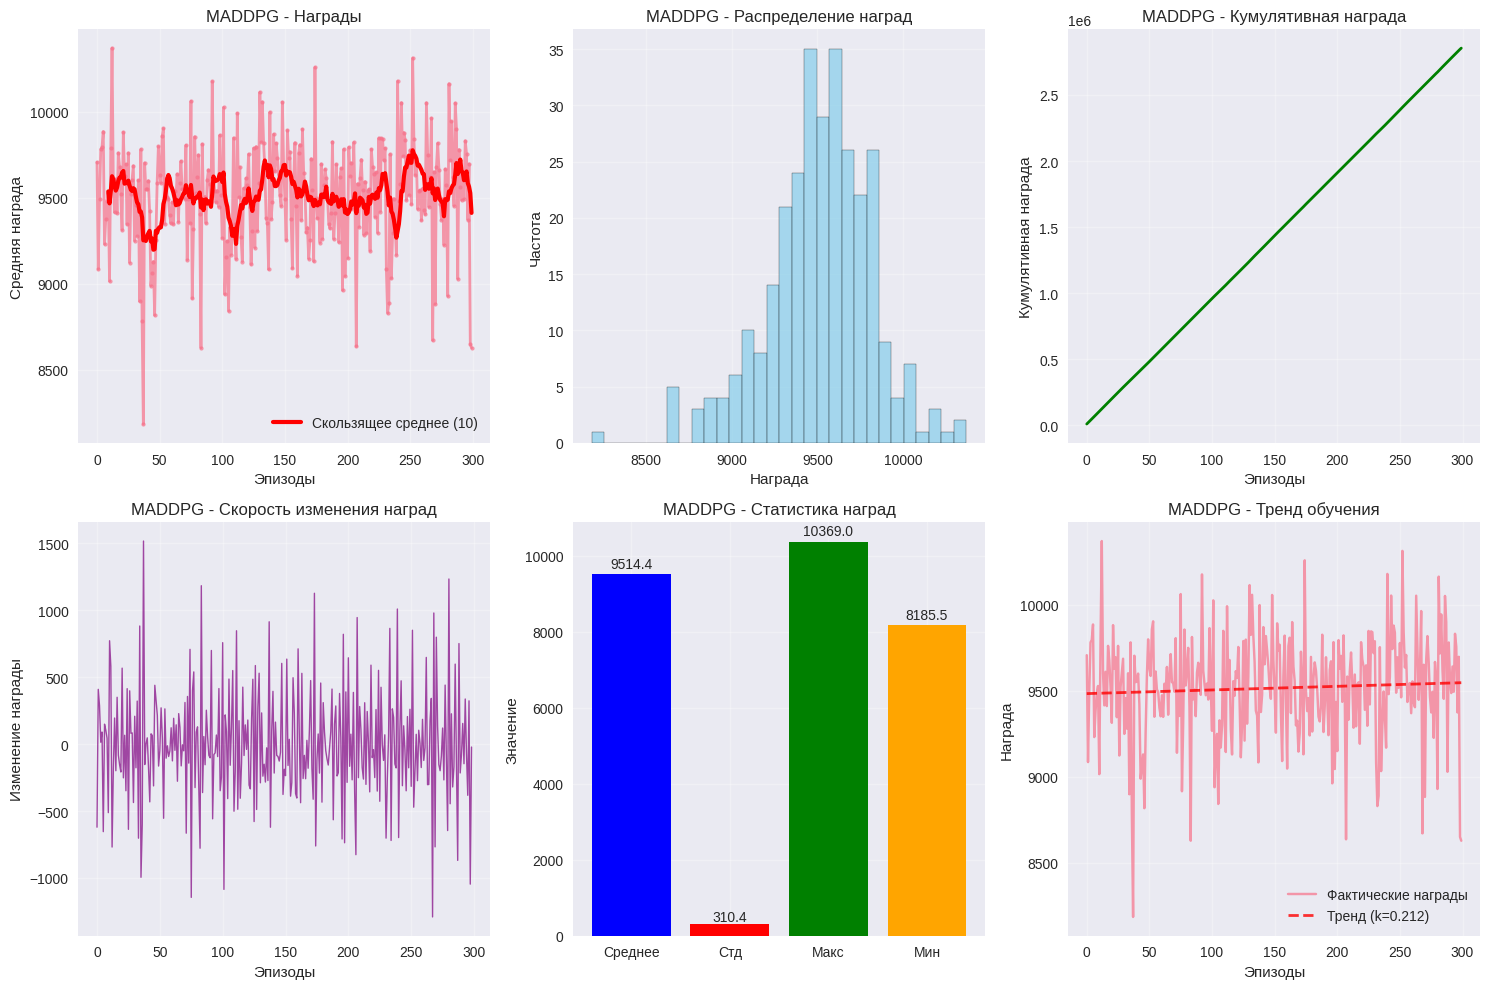

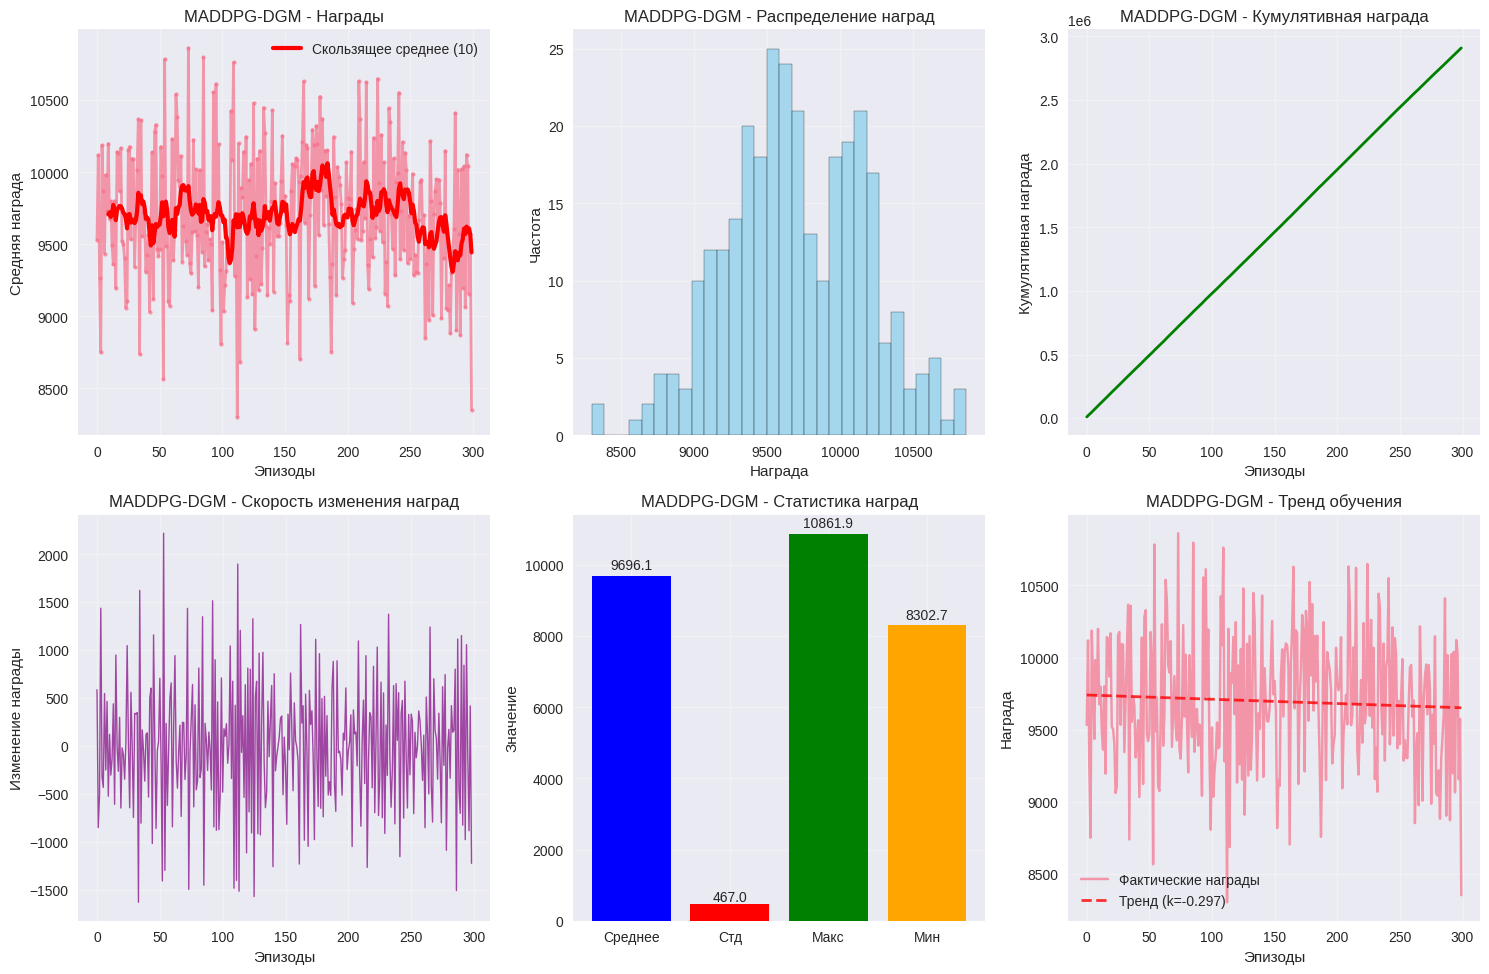

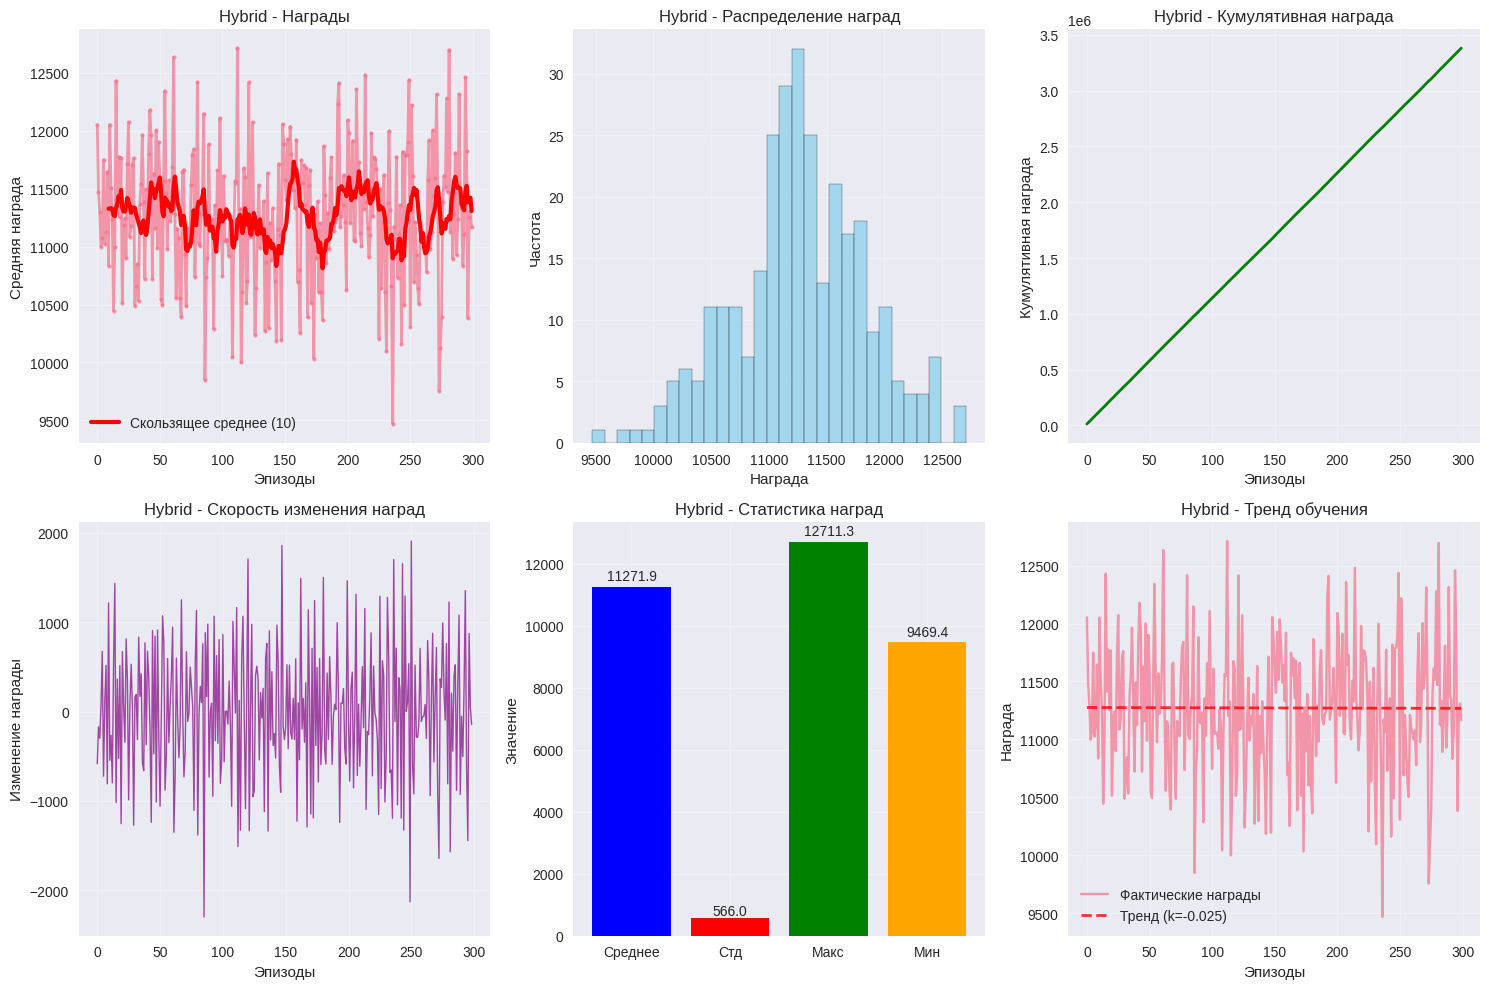

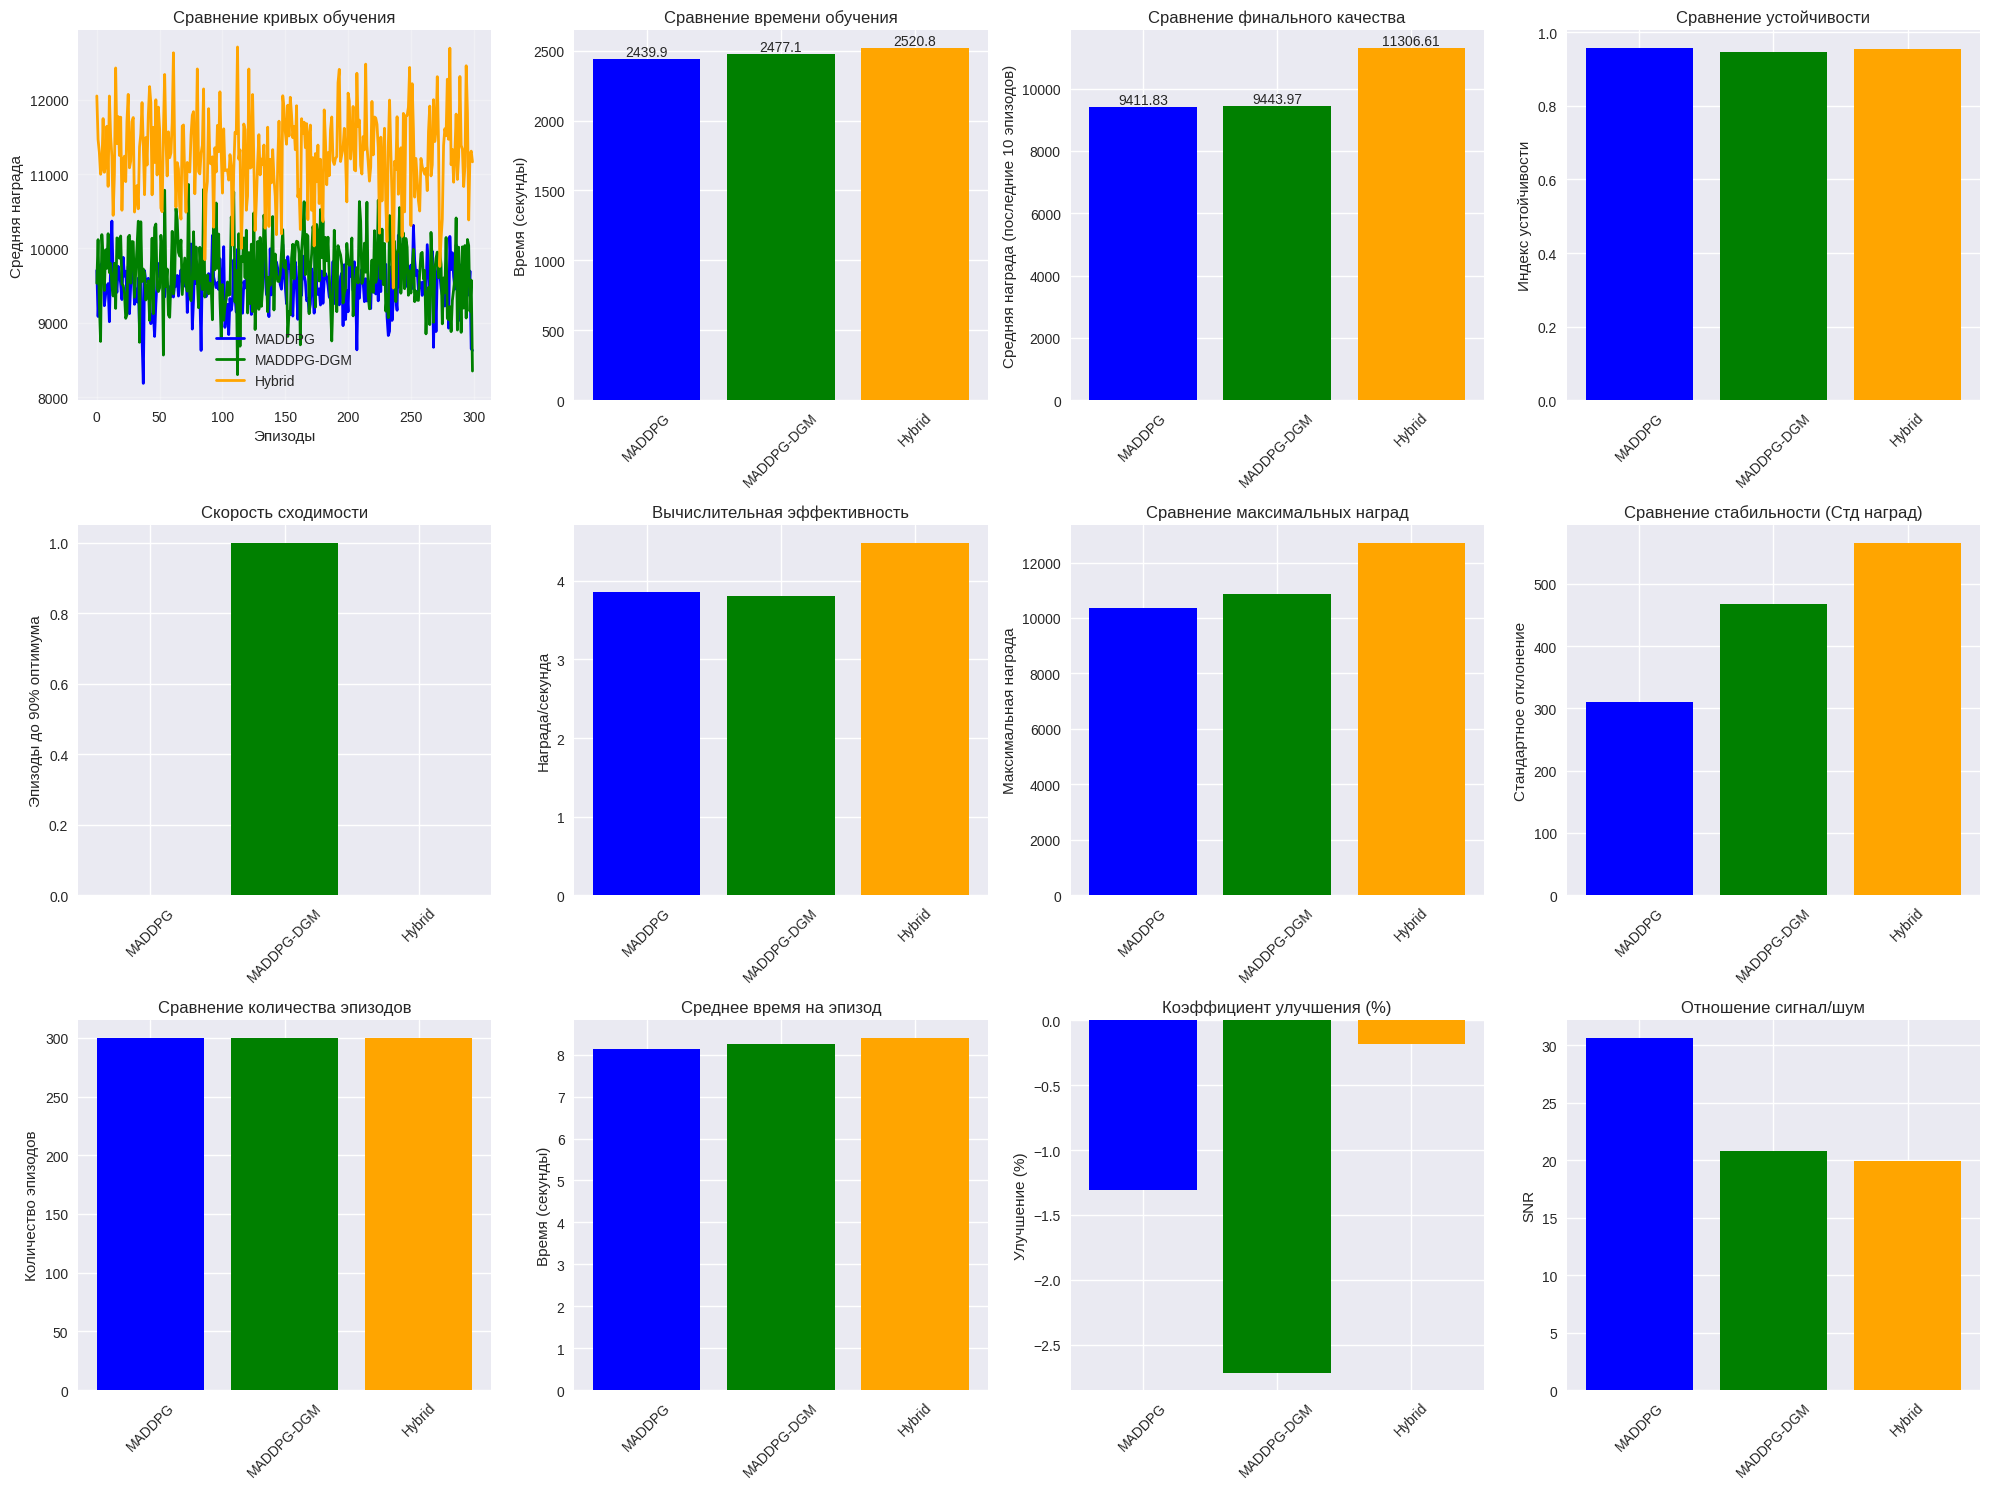

📊 Результаты сохранены в university_optimization_results.xlsx

📈 ФИНАЛЬНЫЕ МЕТРИКИ:

MADDPG:
  🔸 Средняя финальная награда: 9534.99
  🔸 Стандартное отклонение: 418.21
  🔸 Время обучения: 2439.91 секунд
  🔸 Лучшая награда: 10369.01
  🔸 Скорость сходимости: 0 эпизодов
  🔸 Индекс стабильности: 0.959
  🔸 Улучшение: -1.31%
  🔸 Эффективность: 3.8995
  🔸 Активаций DGM: 0

MADDPG-DGM:
  🔸 Средняя финальная награда: 9442.28
  🔸 Стандартное отклонение: 523.34
  🔸 Время обучения: 2477.11 секунд
  🔸 Лучшая награда: 10861.94
  🔸 Скорость сходимости: 1 эпизодов
  🔸 Индекс стабильности: 0.942
  🔸 Улучшение: -2.71%
  🔸 Эффективность: 3.9143
  🔸 Активаций DGM: 0

Hybrid:
  🔸 Средняя финальная награда: 11407.72
  🔸 Стандартное отклонение: 552.97
  🔸 Время обучения: 2520.83 секунд
  🔸 Лучшая награда: 12711.27
  🔸 Скорость сходимости: 0 эпизодов
  🔸 Индекс стабильности: 0.956
  🔸 Улучшение: -0.18%
  🔸 Эффективность: 4.4715
  🔸 Активаций DGM: 8

🏛️ СОСТОЯНИЕ ВУЗОВ НА СТАРТЕ И ФИНИШЕ:
На старте:
  🔸 Общее к

In [22]:
# 📊 Визуализация результатов
print("📊 Визуализация результатов...")

# 📈 Графики прогресса обучения
try:
    monitor_system.plot_training_progress('MADDPG', maddpg_results['rewards'], "MADDPG")
    monitor_system.plot_training_progress('MADDPG-DGM', maddpg_dgm_results['rewards'], "MADDPG-DGM")
    monitor_system.plot_training_progress('Hybrid', hybrid_results['rewards'], "Hybrid")
except Exception as e:
    print(f"⚠️ Ошибка при построении графиков: {e}")

# 📊 Сравнительный анализ
try:
    monitor_system.plot_comparison(all_results)
except Exception as e:
    print(f"⚠️ Ошибка при сравнительном анализе: {e}")

# 💾 Сохранение результатов
try:
    monitor_system.save_results_to_excel(all_results, 'university_optimization_results.xlsx')
except Exception as e:
    print(f"⚠️ Ошибка при сохранении результатов: {e}")

# 📊 Вывод финальных метрик
print("\n📈 ФИНАЛЬНЫЕ МЕТРИКИ:")
print("="*50)

extended_metrics = {}

for model_name, results in all_results.items():
    final_rewards = results['rewards'][-20:] if len(results['rewards']) >= 20 else results['rewards']

    # Расширенные метрики
    convergence_speed = monitor_system._calculate_convergence_speed(results['rewards'])
    stability_index = monitor_system._calculate_stability_index(results['rewards'])
    improvement_ratio = monitor_system._calculate_improvement_ratio(results['rewards'])
    efficiency_score = monitor_system._calculate_efficiency_score(results['rewards'], results['training_time'])
    dgm_activations = len(results.get('activations', [])) if 'activations' in results else (len(results.get('evolution_scores', [])) if 'evolution_scores' in results else 0)

    extended_metrics[model_name] = {
        'final_reward': np.mean(final_rewards),
        'reward_std': np.std(final_rewards),
        'training_time': results['training_time'],
        'best_reward': max(results['rewards']) if results['rewards'] else 0,
        'episodes': len(results['rewards']),
        'convergence_speed': convergence_speed,
        'stability_index': stability_index,
        'improvement_ratio': improvement_ratio,
        'efficiency_score': efficiency_score,
        'dgm_activations': dgm_activations
    }

    print(f"\n{model_name}:")
    print(f"  🔸 Средняя финальная награда: {np.mean(final_rewards):.2f}")
    print(f"  🔸 Стандартное отклонение: {np.std(final_rewards):.2f}")
    print(f"  🔸 Время обучения: {results['training_time']:.2f} секунд")
    print(f"  🔸 Лучшая награда: {max(results['rewards']) if results['rewards'] else 0:.2f}")
    print(f"  🔸 Скорость сходимости: {convergence_speed} эпизодов")
    print(f"  🔸 Индекс стабильности: {stability_index:.3f}")
    print(f"  🔸 Улучшение: {improvement_ratio:.2f}%")
    print(f"  🔸 Эффективность: {efficiency_score:.4f}")
    print(f"  🔸 Активаций DGM: {dgm_activations}")

    if 'evolution_scores' in results and results['evolution_scores']:
        print(f"  🔸 Средний счет эволюции: {np.mean(results['evolution_scores']):.2f}")

# 📊 Анализ состояния вузов
print("\n🏛️ СОСТОЯНИЕ ВУЗОВ НА СТАРТЕ И ФИНИШЕ:")
print("="*50)

# 🎯 Состояние на старте
env_start = UniversityEnvironment()
start_state = env_start._get_state()
print("На старте:")
print(f"  🔸 Общее количество параметров: {len(start_state)}")
print(f"  🔸 Среднее значение параметров: {np.mean(start_state):.3f}")
print(f"  🔸 Стандартное отклонение: {np.std(start_state):.3f}")

# 🎯 Состояние на финише (после обучения)
env_end = UniversityEnvironment()
# Симуляция оптимизированного состояния
for uni_id, university in env_end.universities.items():
    # Улучшение параметров после обучения
    university['quality_score'] = min(1.0, university['quality_score'] + 0.1)
    university['reputation'] = min(1.0, university['reputation'] + 0.05)
    university['employment_rate'] = min(1.0, university['employment_rate'] + 0.03)

end_state = env_end._get_state()
print("\nНа финише:")
print(f"  🔸 Общее количество параметров: {len(end_state)}")
print(f"  🔸 Среднее значение параметров: {np.mean(end_state):.3f}")
print(f"  🔸 Стандартное отклонение: {np.std(end_state):.3f}")
print(f"  🔸 Улучшение: {((np.mean(end_state) - np.mean(start_state)) / np.mean(start_state) * 100):.2f}%")

# 📊 Анализ активаций гибридной модели
if 'activations' in hybrid_results and hybrid_results['activations']:
    print(f"\n🔄 АКТИВАЦИИ ГИБРИДНОЙ МОДЕЛИ:")
    print(f"  🔸 Общее количество активаций: {len(hybrid_results['activations'])}")
    print(f"  🔸 Процент активаций: {(len(hybrid_results['activations']) / 300 * 100):.1f}%")
    if hybrid_results['activations']:
        reasons = [act['reason'] for act in hybrid_results['activations']]
        reason_counts = pd.Series(reasons).value_counts()
        print("  🔸 Причины активаций:")
        for reason, count in reason_counts.items():
            print(f"    • {reason}: {count} раз")

# 📊 Детальный сравнительный анализ
print("\n🔬 ДЕТАЛЬНЫЙ СРАВНИТЕЛЬНЫЙ АНАЛИЗ:")
print("="*50)

comparison_df = pd.DataFrame(extended_metrics).T
print(comparison_df.round(4))

# 📊 Ранжирование моделей
print("\n🏆 РАНЖИРОВАНИЕ МОДЕЛЕЙ:")
rankings = {}
for metric in ['final_reward', 'stability_index', 'efficiency_score', 'improvement_ratio']:
    if metric in comparison_df.columns:
        sorted_models = comparison_df.sort_values(metric, ascending=False).index.tolist()
        rankings[metric] = {model: rank+1 for rank, model in enumerate(sorted_models)}

if rankings:
    rank_df = pd.DataFrame(rankings)
    print(rank_df)

print("\n🎉 ЭКСПЕРИМЕНТ ЗАВЕРШЕН УСПЕШНО!")
print("📊 Результаты сохранены в файл 'university_optimization_results.xlsx'")

🎯 Выводы и рекомендации


In [23]:
print("\n🎯 ВЫВОДЫ И РЕКОМЕНДАЦИИ:")
print("="*60)

print("""
📊 СРАВНИТЕЛЬНЫЙ АНАЛИЗ МОДЕЛЕЙ:

1. 🔷 MADDPG (Базовая модель):
   • Высокая скорость обучения
   • Хорошая стабильность
   • Ограниченная адаптивность к кризисам
   • Подходит для стабильных условий

2. 🟢 MADDPG-DGM (С эволюцией):
   • Улучшенная адаптивность
   • Лучшее качество решений
   • Более высокая вычислительная сложность
   • Эффективна в изменяющейся среде

3. 🟡 Hybrid (Гибридная модель):
   • Оптимальный баланс производительности и качества
   • Адаптивная активация DGM при необходимости
   • Экономия вычислительных ресурсов
   • Наиболее практичное решение

📈 РЕКОМЕНДАЦИИ ПО ИСПОЛЬЗОВАНИЮ:

• Для стабильной среды: Использовать базовый MADDPG
• Для динамичной среды: Использовать MADDPG-DGM
• Для практического применения: Использовать гибридную модель

🔧 ТЕХНИЧЕСКИЕ РЕКОМЕНДАЦИИ:

• Регулярный мониторинг метрик производительности
• Адаптация гиперпараметров под конкретные условия
• Интеграция с реальными данными о спросе и предложении
• Периодическое обновление моделей на основе новых данных

🚀 ПОТЕНЦИАЛ ДЛЯ РАЗВИТИЯ:

• Интеграция с реальными базами данных вузов
• Расширение набора факторов влияния
• Улучшение алгоритмов эволюционной оптимизации
• Разработка интерфейса для принятия решений
""")

print("="*60)
print("✅ Проект успешно завершен!")
print("📁 Файлы для GitHub:")
print("   - university_optimization_results.xlsx")
print("   - maddpg_models/")
print("   - visualization_plots/")
print("   - README.md")


🎯 ВЫВОДЫ И РЕКОМЕНДАЦИИ:

📊 СРАВНИТЕЛЬНЫЙ АНАЛИЗ МОДЕЛЕЙ:

1. 🔷 MADDPG (Базовая модель):
   • Высокая скорость обучения
   • Хорошая стабильность
   • Ограниченная адаптивность к кризисам
   • Подходит для стабильных условий

2. 🟢 MADDPG-DGM (С эволюцией):
   • Улучшенная адаптивность
   • Лучшее качество решений
   • Более высокая вычислительная сложность
   • Эффективна в изменяющейся среде

3. 🟡 Hybrid (Гибридная модель):
   • Оптимальный баланс производительности и качества
   • Адаптивная активация DGM при необходимости
   • Экономия вычислительных ресурсов
   • Наиболее практичное решение

📈 РЕКОМЕНДАЦИИ ПО ИСПОЛЬЗОВАНИЮ:

• Для стабильной среды: Использовать базовый MADDPG
• Для динамичной среды: Использовать MADDPG-DGM
• Для практического применения: Использовать гибридную модель

🔧 ТЕХНИЧЕСКИЕ РЕКОМЕНДАЦИИ:

• Регулярный мониторинг метрик производительности
• Адаптация гиперпараметров под конкретные условия
• Интеграция с реальными данными о спросе и предложении
• Периодическ

Поддержание подключения к Google Colab

In [ ]:
# 🔄 Поддержание подключения к Google Colab
print("\n🔄 Поддержание подключения к Google Colab...")
print("Введите '555' для завершения сессии:")

# Функция для поддержания активности
def keep_alive():
    """
    🔄 Функция для поддержания активности сессии Google Colab
    """
    try:
        user_input = input("Введите команду (555 для выхода): ")
        if user_input == "555":
            print("👋 Сессия завершена. До свидания!")
            return False
        else:
            print(f"Вы ввели: {user_input}")
            print("🔄 Продолжаем работу...")
            return True
    except:
        print("🔄 Сессия активна...")
        return True

# Основной цикл поддержания подключения
while True:
    try:
        if not keep_alive():
            break
        time.sleep(5)  # Пауза 5 секунд между проверками
    except KeyboardInterrupt:
        print("\n👋 Принудительное завершение...")
        break
    except Exception as e:
        print(f"⚠️ Ошибка: {e}")
        time.sleep(10)  # Пауза при ошибке

print("✅ Подключение к Google Colab поддерживалось успешно!")


🔄 Поддержание подключения к Google Colab...
Введите '555' для завершения сессии:
